#Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.impute import KNNImputer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

#Loading Data Set

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path_train = '/content/drive/MyDrive/Project ITI/aug_train.csv'
file_path_test = '/content/drive/MyDrive/Project ITI/aug_test.csv'

In [4]:
df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

display(df_train.head())
display(df_test.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


#EDA

In [5]:
df_train.shape

(19158, 14)

In [6]:
#data types of dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
#check for missing values
df_train.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


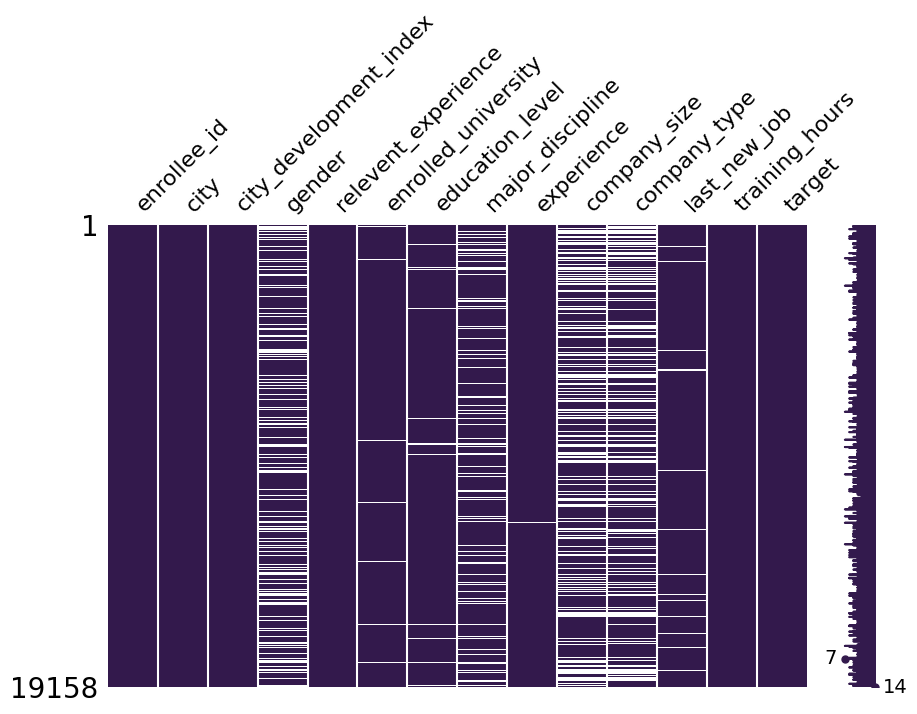

In [8]:
#Show the distribution of missing values
#Plot the matrix
msno.matrix(df_train, figsize=(10, 6), color=(0.2, 0.1, 0.3))
plt.show()

In [9]:

# Calculate percentage of missing values
null_percentages = (df_train.isnull().sum() / len(df_train)) * 100

# Filter for columns that have missing data and sort them
null_df = null_percentages[null_percentages > 0].sort_values(ascending=False).to_frame(name='Missing Percentage (%)')

print("--- PERCENTAGE OF NULL VALUES ---")
print(null_df)

--- PERCENTAGE OF NULL VALUES ---
                     Missing Percentage (%)
company_type                      32.049274
company_size                      30.994885
gender                            23.530640
major_discipline                  14.683161
education_level                    2.401086
last_new_job                       2.207955
enrolled_university                2.014824
experience                         0.339284


In [10]:
# check for duplicates
df_train.duplicated().sum()

np.int64(0)

In [11]:
print("\n--- STATISTICS (NUMERICAL) ---")
print(df_train.describe())

#View statistics for categorical/text columns
print("\n--- STATISTICS (CATEGORICAL) ---")
print(df_train.describe(include=['object']))


--- STATISTICS (NUMERICAL) ---
        enrollee_id  city_development_index  training_hours        target
count  19158.000000            19158.000000    19158.000000  19158.000000
mean   16875.358179                0.828848       65.366896      0.249348
std     9616.292592                0.123362       60.058462      0.432647
min        1.000000                0.448000        1.000000      0.000000
25%     8554.250000                0.740000       23.000000      0.000000
50%    16982.500000                0.903000       47.000000      0.000000
75%    25169.750000                0.920000       88.000000      0.000000
max    33380.000000                0.949000      336.000000      1.000000

--- STATISTICS (CATEGORICAL) ---
            city gender      relevent_experience enrolled_university  \
count      19158  14650                    19158               18772   
unique       123      3                        2                   3   
top     city_103   Male  Has relevent experience    

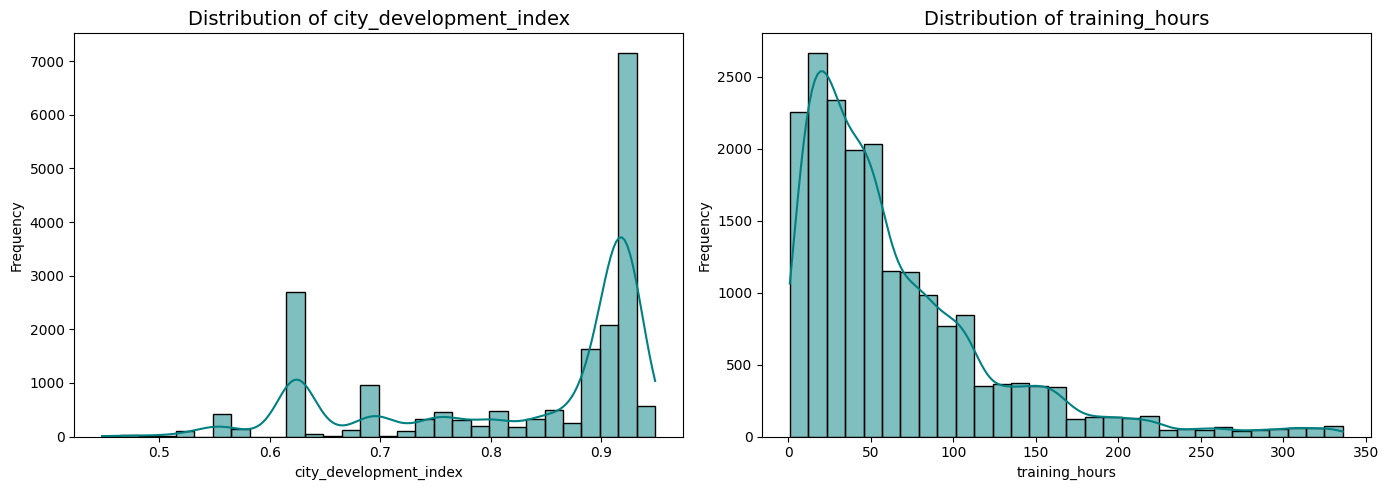

In [12]:
#Distribution of Numerical Columns
num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()

plt.show()


/tmp/ipykernel_3034/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_3034/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_3034/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_3034/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning 

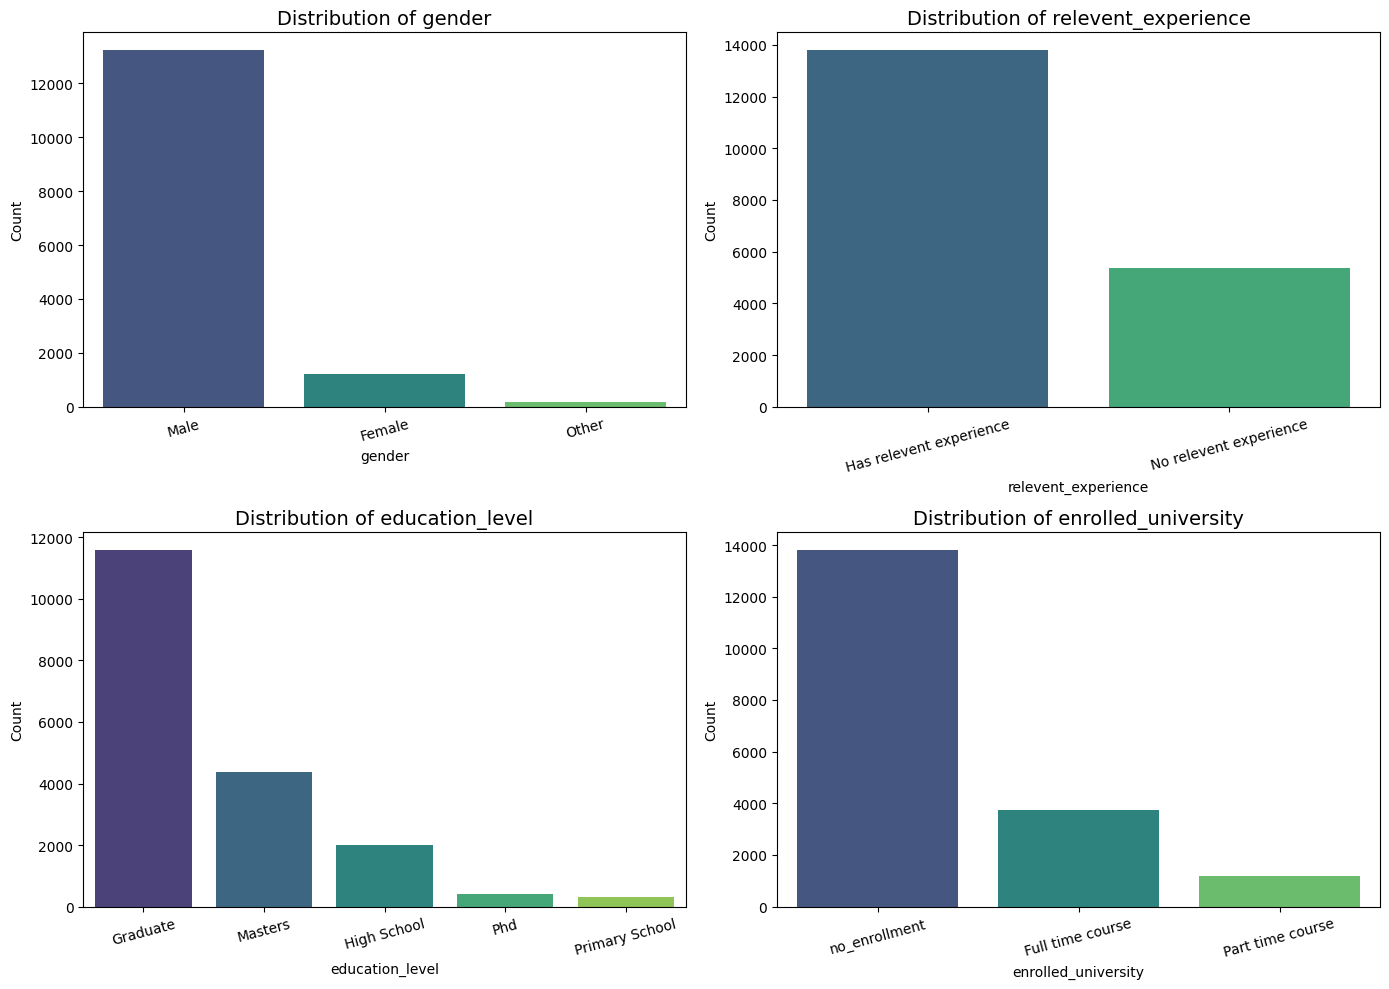

In [13]:
#Distribution of Categorical Columns
cat_cols = ['gender', 'relevent_experience', 'education_level', 'enrolled_university']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Order the bars by count for better readability
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()

plt.show()

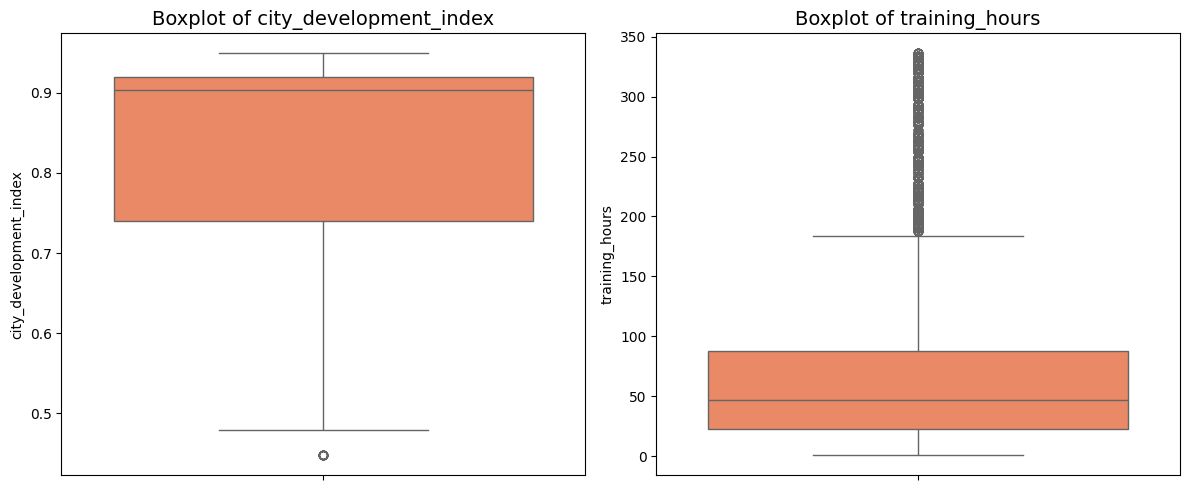

--- OUTLIER DETECTION (IQR METHOD) ---
city_development_index:
  - Number of Outliers: 17
  - Bounds: Lower 0.470, Upper 1.190
  - Percentage: 0.09%

training_hours:
  - Number of Outliers: 984
  - Bounds: Lower -74.500, Upper 185.500
  - Percentage: 5.14%



In [14]:

num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)

plt.tight_layout()
plt.savefig('outliers_boxplot.png')
plt.show()

#Calculating Outliers using IQR Method
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("--- OUTLIER DETECTION (IQR METHOD) ---")
for col in num_cols:
    num_outliers, lower, upper = count_outliers(df_train[col])
    print(f"{col}:")
    print(f"  - Number of Outliers: {num_outliers}")
    print(f"  - Bounds: Lower {lower:.3f}, Upper {upper:.3f}")
    print(f"  - Percentage: {(num_outliers / len(df_train)) * 100:.2f}%\n")

/tmp/ipykernel_3034/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
/tmp/ipykernel_3034/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
/tmp/ipykernel_3034/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')


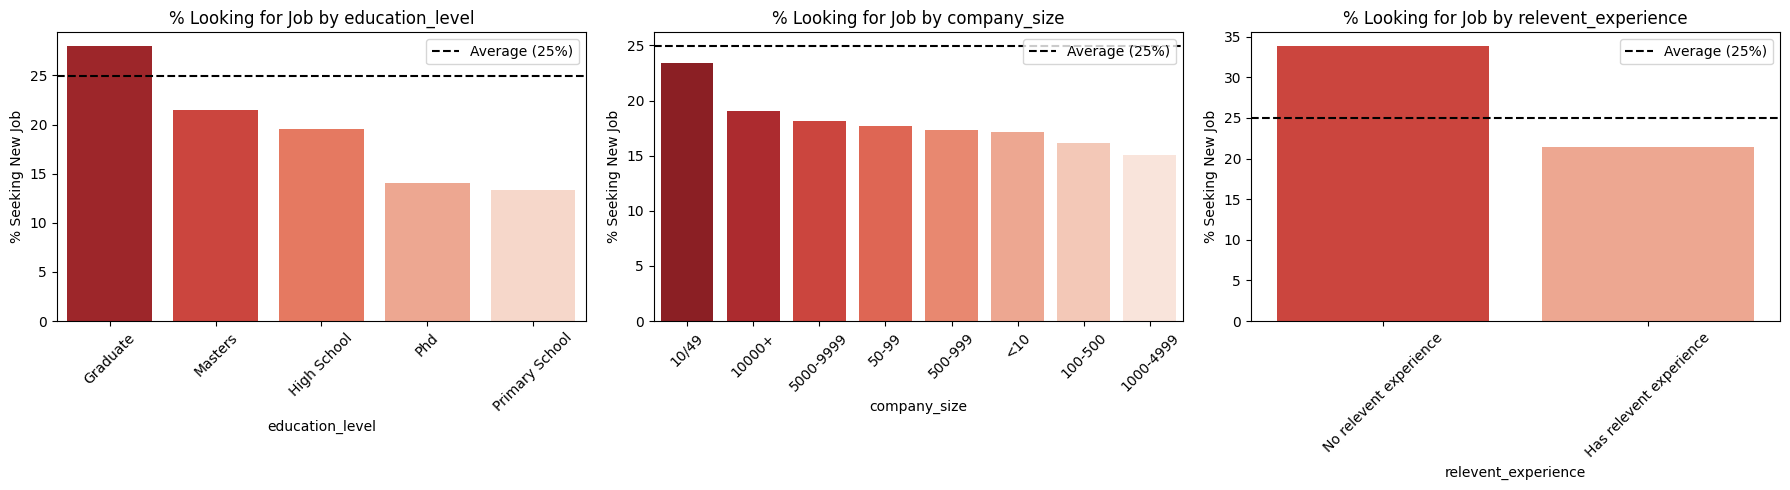

In [15]:
#Bivariate Analysis: Target vs Categorical Features
features_to_check = ['education_level', 'company_size', 'relevent_experience']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_check):
    # Calculate percentage of target=1 for each category
    target_pct = df_train.groupby(col)['target'].mean().sort_values(ascending=False) * 100

    sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'% Looking for Job by {col}', fontsize=12)
    axes[i].set_ylabel('% Seeking New Job')
    axes[i].tick_params(axis='x', rotation=45)

    # Add horizontal line for dataset average
    axes[i].axhline(df_train['target'].mean() * 100, color='black', linestyle='--', label='Average (25%)')
    axes[i].legend()

plt.tight_layout()
plt.show()

#Preprocessing

##Handling missing values

In [16]:
# 1. Handle Categorical Missing Values ONLY
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns

# Fill missing text cells with "Unknown" without touching numbers
df_train[categorical_cols] = df_train[categorical_cols].fillna("Unknown")
df_test[categorical_cols] = df_test[categorical_cols].fillna("Unknown")

In [17]:


# 2. Handle Numerical Missing Values using KNN Imputer
numeric_features = ['city_development_index', 'training_hours'] # Update with your exact numerical columns that might have NaNs

# Initialize KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')


if numeric_features:
    df_train[numeric_features] = knn_imputer.fit_transform(df_train[numeric_features])

    # Transform the test set using the same fitted imputer (prevents data leakage)
    df_test[numeric_features] = knn_imputer.transform(df_test[numeric_features])
else:
    print("No numerical features with missing values found for KNN imputation in this step.")

# 3. Verification
print("Missing values in Train data after KNN + Unknown fix:", df_train.isnull().sum().sum())
print("Missing values in Test data after KNN + Unknown fix:", df_test.isnull().sum().sum())

Missing values in Train data after KNN + Unknown fix: 0
Missing values in Test data after KNN + Unknown fix: 0


In [18]:
print("Missing values in Train data after cleaning:", df_train.isnull().sum().sum())
print("Missing values in Train data after cleaning:", df_test.isnull().sum().sum())

Missing values in Train data after cleaning: 0
Missing values in Train data after cleaning: 0


##Handling Outliers

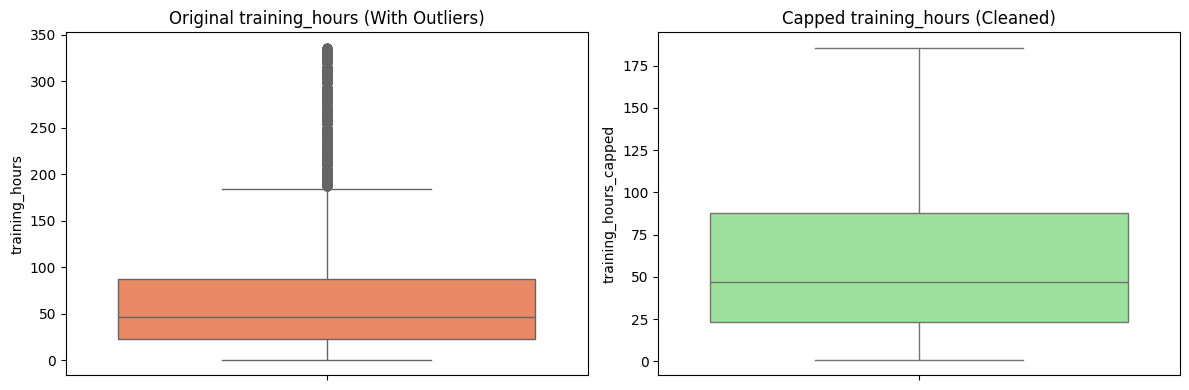

In [19]:
#Handle Outliers in training_hours
Q1 = df_train['training_hours'].quantile(0.25)
Q3 = df_train['training_hours'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR


df_train['training_hours_capped'] = df_train['training_hours'].clip(upper=upper_bound)


df_test['training_hours_capped'] = df_test['training_hours'].clip(upper=upper_bound)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_train['training_hours'], ax=axes[0], color='coral')
axes[0].set_title('Original training_hours (With Outliers)')

sns.boxplot(y=df_train['training_hours_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title('Capped training_hours (Cleaned)')

plt.tight_layout()
plt.show()

##Encoding

In [20]:

#Education level Ordinal Encoding
education_level_mapping = {
    'Unknown': -1,
    'Primary School': 0,
    'High School': 1,
    'Graduate': 2,
    'Masters': 3,
    'Phd': 4
}


df_train['education_level_encoded'] = df_train['education_level'].map(education_level_mapping)
df_test['education_level_encoded'] = df_test['education_level'].map(education_level_mapping)

In [21]:
#Relevant experience Ordinal Encoding
relevent_experience_mapping = {
    'No relevent experience': 0,
    'Has relevent experience': 1
}

df_train['relevent_experience_encoded'] = df_train['relevent_experience'].map(relevent_experience_mapping)
df_test['relevent_experience_encoded'] = df_test['relevent_experience'].map(relevent_experience_mapping)

In [22]:
#Experience Ordinal Encoding
experience_mapping = {
    'Unknown': -1,
    '<1': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6': 6,
    '7': 7,
    '8': 8,
    '9': 9,
    '10': 10,
    '11': 11,
    '12': 12,
    '13': 13,
    '14': 14,
    '15': 15,
    '16': 16,
    '17': 17,
    '18': 18,
    '19': 19,
    '20': 20,
    '>20': 21,
}

df_train['experience_encoded'] = df_train['experience'].map(experience_mapping).fillna(0)
df_test['experience_encoded'] = df_test['experience'].map(experience_mapping).fillna(0)

In [23]:
#Company size Ordinal Encoding
company_size_mapping = {
    'Unknown': -1,
    '<10': 0,
    '10-49': 1,
    '10/49': 1,
    '50-99': 2,
    '100-500': 3,
    '500-999': 4,
    '1000-4999': 5,
    '5000-9999': 6,
    '10000+': 7
}

df_train['company_size_encoded'] = df_train['company_size'].map(company_size_mapping)
df_test['company_size_encoded'] = df_test['company_size'].map(company_size_mapping)

In [24]:
#LNJ Ordinal Encoding
last_new_job_mapping = {
    'Unknown': -1,
    'never': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '>4': 5
}

df_train['last_new_job_encoded'] = df_train['last_new_job'].map(last_new_job_mapping).fillna(0)
df_test['last_new_job_encoded'] = df_test['last_new_job'].map(last_new_job_mapping).fillna(0)

In [25]:
#Enrolled Uni Ordinal Encoding
enrolled_university_mapping = {
    'Unknown': -1 ,
    'no_enrollment': 0,
    'Full time course': 1,
    'Part time course': 2


}

df_train['enrolled_university_encoded'] = df_train['enrolled_university'].map(enrolled_university_mapping)
df_test['enrolled_university_encoded'] = df_test['enrolled_university'].map(enrolled_university_mapping)

In [26]:
display(df_train.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,last_new_job,training_hours,target,training_hours_capped,education_level_encoded,relevent_experience_encoded,experience_encoded,company_size_encoded,last_new_job_encoded,enrolled_university_encoded
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,...,1,36.0,1.0,36.0,2,1,21,-1,1.0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,>4,47.0,0.0,47.0,2,0,15,2,5.0,0
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,...,never,83.0,0.0,83.0,2,0,5,-1,0.0,1
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,...,never,52.0,1.0,52.0,2,0,0,-1,0.0,-1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,4,8.0,0.0,8.0,3,1,21,2,0.0,0


In [27]:
#City Frequency Encoding
city_freq_map = df_train['city'].value_counts(normalize=True).to_dict()


df_train['city_freq'] = df_train['city'].map(city_freq_map)
df_test['city_freq'] = df_test['city'].map(city_freq_map).fillna(0)

train = df_train.drop(columns=['city'])
test = df_test.drop(columns=['city'])

In [28]:
#major_discipline One Hot Encoding
major_discipline_dummies_train = pd.get_dummies(df_train['major_discipline'], prefix='major_discipline')
major_discipline_dummies_test = pd.get_dummies(df_test['major_discipline'], prefix='major_discipline')

train_cols = major_discipline_dummies_train.columns
test_cols = major_discipline_dummies_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    major_discipline_dummies_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    major_discipline_dummies_train[c] = 0

major_discipline_dummies_test = major_discipline_dummies_test[train_cols]

df_train = pd.concat([df_train, major_discipline_dummies_train], axis=1)
df_test = pd.concat([df_test, major_discipline_dummies_test], axis=1)

df_train.drop(columns=['major_discipline'], inplace=True)
df_test.drop(columns=['major_discipline'], inplace=True)

In [29]:
display(df_train.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,experience,company_size,company_type,...,last_new_job_encoded,enrolled_university_encoded,city_freq,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,>20,Unknown,Unknown,...,1.0,0,0.227320,False,False,False,False,False,True,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,15,50-99,Pvt Ltd,...,5.0,0,0.003549,False,False,False,False,False,True,False
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,5,Unknown,Unknown,...,0.0,1,0.141038,False,False,False,False,False,True,False
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,<1,Unknown,Pvt Ltd,...,0.0,-1,0.002819,False,True,False,False,False,False,False
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,>20,50-99,Funded Startup,...,0.0,0,0.006681,False,False,False,False,False,True,False


In [30]:
#Gender One Hot Encoding
gender_dummies_train = pd.get_dummies(df_train['gender'], prefix='gender')
gender_dummies_test = pd.get_dummies(df_test['gender'], prefix='gender')


train_cols_gender = gender_dummies_train.columns
test_cols_gender = gender_dummies_test.columns

missing_in_test_gender = set(train_cols_gender) - set(test_cols_gender)
for c in missing_in_test_gender:
    gender_dummies_test[c] = 0

missing_in_train_gender = set(test_cols_gender) - set(train_cols_gender)
for c in missing_in_train_gender:
    gender_dummies_train[c] = 0

gender_dummies_test = gender_dummies_test[train_cols_gender]

df_train = pd.concat([df_train, gender_dummies_train], axis=1)
df_test = pd.concat([df_test, gender_dummies_test], axis=1)

df_train.drop(columns=['gender'], inplace=True)
df_test.drop(columns=['gender'], inplace=True)

In [31]:
display(df_train.head())

,enrollee_id,city,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,company_type,last_new_job,...,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,gender_Female,gender_Male,gender_Other,gender_Unknown
0,8949,city_103,0.920,Has relevent experience,no_enrollment,Graduate,>20,Unknown,Unknown,1,...,False,False,False,False,True,False,False,True,False,False
1,29725,city_40,0.776,No relevent experience,no_enrollment,Graduate,15,50-99,Pvt Ltd,>4,...,False,False,False,False,True,False,False,True,False,False
2,11561,city_21,0.624,No relevent experience,Full time course,Graduate,5,Unknown,Unknown,never,...,False,False,False,False,True,False,False,False,False,True
3,33241,city_115,0.789,No relevent experience,Unknown,Graduate,<1,Unknown,Pvt Ltd,never,...,True,False,False,False,False,False,False,False,False,True
4,666,city_162,0.767,Has relevent experience,no_enrollment,Masters,>20,50-99,Funded Startup,4,...,False,False,False,False,True,False,False,True,False,False


In [32]:
#Company type One Hot Encoding
company_type_dummies_train = pd.get_dummies(df_train['company_type'], prefix='company_type')
company_type_dummies_test = pd.get_dummies(df_test['company_type'], prefix='company_type')

train_cols_company_type = company_type_dummies_train.columns
test_cols_company_type = company_type_dummies_test.columns

missing_in_test_company_type = set(train_cols_company_type) - set(test_cols_company_type)
for c in missing_in_test_company_type:
    company_type_dummies_test[c] = 0

missing_in_train_company_type = set(test_cols_company_type) - set(train_cols_company_type)
for c in missing_in_train_company_type:
    company_type_dummies_train[c] = 0

company_type_dummies_test = company_type_dummies_test[train_cols_company_type]

df_train = pd.concat([df_train, company_type_dummies_train], axis=1)
df_test = pd.concat([df_test, company_type_dummies_test], axis=1)

df_train.drop(columns=['company_type'], inplace=True)
df_test.drop(columns=['company_type'], inplace=True)

In [33]:
display(df_train.head())

,enrollee_id,city,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,...,gender_Male,gender_Other,gender_Unknown,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,8949,city_103,0.920,Has relevent experience,no_enrollment,Graduate,>20,Unknown,1,36.0,...,True,False,False,False,False,False,False,False,False,True
1,29725,city_40,0.776,No relevent experience,no_enrollment,Graduate,15,50-99,>4,47.0,...,True,False,False,False,False,False,False,False,True,False
2,11561,city_21,0.624,No relevent experience,Full time course,Graduate,5,Unknown,never,83.0,...,False,False,True,False,False,False,False,False,False,True
3,33241,city_115,0.789,No relevent experience,Unknown,Graduate,<1,Unknown,never,52.0,...,False,False,True,False,False,False,False,False,True,False
4,666,city_162,0.767,Has relevent experience,no_enrollment,Masters,>20,50-99,4,8.0,...,True,False,False,False,True,False,False,False,False,False


#Modeling

In [34]:
from sklearn.inspection import permutation_importance

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cols_to_drop_train = [
    'target',
    'enrollee_id',
    'city',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'experience',
    'company_size',
    'last_new_job',
    'training_hours'
]

cols_to_drop_test = [
    'enrollee_id',
    'city',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'experience',
    'company_size',
    'last_new_job',
    'training_hours'
]

X_train = df_train.drop(columns=cols_to_drop_train)
X_test = df_test.drop(columns=cols_to_drop_test)
y_train = df_train['target']

X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

X_test = X_test[X_train.columns]


##Handling Imbalance with SMOTE

Given the imbalance observed in the target variable, we will employ the Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples of the minority class. This helps to provide a more balanced dataset for training, which can improve model performance, especially in terms of recall for the minority class. SMOTE will be incorporated into the modeling pipelines to ensure it's applied correctly within cross-validation folds, preventing data leakage.

In [35]:
#  Initialize the SMOTE object
smote = SMOTE(random_state=42)

##Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Logistic Regression with SMOTE
logreg_smote = LogisticRegression(max_iter=2000, random_state=42)

# Using imblearn Pipeline to include SMOTE
pipeline_lr_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('model', logreg_smote)
])

print("Evaluating Logistic Regression + SMOTE...")
scores_lr_smote = cross_val_score(pipeline_lr_smote, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"SMOTE CV ROC-AUC Score: {scores_lr_smote.mean():.4f} +/- {scores_lr_smote.std():.4f}")

Evaluating Logistic Regression + SMOTE...
SMOTE CV ROC-AUC Score: 0.7704 +/- 0.0059


In [37]:
from sklearn.feature_selection import SelectFromModel

rf_for_selection = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
feature_selector = SelectFromModel(rf_for_selection, threshold='median')

logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', feature_selector),
    ('model', logreg) ])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Evaluating model with feature selection...")
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC Score: {scores.mean():.4f} +/- {scores.std():.4f}")

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv)



Evaluating model with feature selection...
CV ROC-AUC Score: 0.7615 +/- 0.0041


In [38]:
# 1. Classification Report for Logistic Regression
print("\n--- Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv))


--- Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.88      0.75      0.81     14381
         1.0       0.48      0.69      0.56      4777

    accuracy                           0.73     19158
   macro avg       0.68      0.72      0.69     19158
weighted avg       0.78      0.73      0.75     19158



##Random Forest Model

In [39]:
#Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,  class_weight='balanced', random_state=42, n_jobs=-1)


rf_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Random Forest CV ROC-AUC: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

results['Random Forest'] = {'cv_auc_mean': rf_scores.mean(), 'cv_auc_std': rf_scores.std()}


y_pred_cv_rf = cross_val_predict(rf_model, X_train, y_train, cv=cv)

print("\n--- Random Forest Cross-Validated Classification Report ---")

print(classification_report(y_train, y_pred_cv_rf))

Random Forest CV ROC-AUC: 0.7835 +/- 0.0050

--- Random Forest Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86     14381
         1.0       0.57      0.45      0.50      4777

    accuracy                           0.78     19158
   macro avg       0.70      0.67      0.68     19158
weighted avg       0.76      0.78      0.77     19158



##Random Forest Hyperparameter Tuning

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Random Forest with SMOTE within Pipeline
rf_smote_pipeline = ImbPipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Tuning Random Forest with SMOTE
rf_param_dist_smote = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

rf_random_smote = RandomizedSearchCV(
    rf_smote_pipeline,
    param_distributions=rf_param_dist_smote,
    n_iter=5,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_random_smote.fit(X_train, y_train)
print(f"Best RF + SMOTE CV ROC-AUC: {rf_random_smote.best_score_:.4f}")

Best RF + SMOTE CV ROC-AUC: 0.7951


In [41]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(f"Best RF Params: {rf_random.best_params_}")
print(f"Best RF CV ROC-AUC: {rf_random.best_score_:.4f}")


results['Random Forest (Tuned)'] = {'cv_auc_mean': rf_random.best_score_, 'cv_auc_std': rf_random.cv_results_['std_test_score'][rf_random.best_index_]}

Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Best RF CV ROC-AUC: 0.8008


In [42]:
# 1. Classification Report for Tuned Random Forest
y_pred_cv_rf_tuned = cross_val_predict(rf_random.best_estimator_, X_train, y_train, cv=cv)
print("Tuned Random Forest Cross-Validated Classification Report")
print(classification_report(y_train, y_pred_cv_rf_tuned))

Tuned Random Forest Cross-Validated Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.72      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158



##XGBOOST

In [43]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

Calculated Imbalance Ratio: 3.01


In [44]:

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb_model)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\nEvaluating XGBoost model...")
xgb_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"XGBoost CV ROC-AUC Score: {xgb_scores.mean():.4f} +/- {xgb_scores.std():.4f}")

results['XGBoost'] = {'cv_auc_mean': xgb_scores.mean(), 'cv_auc_std': xgb_scores.std()}
y_pred_cv_xgb = cross_val_predict(xgb_pipeline, X_train, y_train, cv=cv)


Calculated Imbalance Ratio: 3.01

Evaluating XGBoost model...
XGBoost CV ROC-AUC Score: 0.8003 +/- 0.0041


In [45]:
# 1. Classification Report for XGBoost
print("\n--- XGBoost Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv_xgb))


--- XGBoost Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85     14381
         1.0       0.55      0.74      0.63      4777

    accuracy                           0.78     19158
   macro avg       0.72      0.77      0.74     19158
weighted avg       0.81      0.78      0.79     19158



Smote XGBOOST

In [46]:
#  Initialize SMOTE
# random_state ensures reproducibility
smote = SMOTE(random_state=42)

#  Re-initialize my classifier
smote_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

#  Create an Imbalanced-Learn Pipeline
# This ensures SMOTE is ONLY applied to the training folds during cross-validation
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('classifier', smote_xgb)
])

# 4. Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [47]:
# 5. Evaluate the Pipeline
print("Evaluating model with SMOTE...")
smote_scores = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"SMOTE + XGBoost CV ROC-AUC Score: {smote_scores.mean():.4f} +/- {smote_scores.std():.4f}")

# 6. Generate Classification Report using cross-validation predictions
y_pred_smote = cross_val_predict(smote_pipeline, X_train, y_train, cv=cv)

print("\n--- SMOTE + XGBoost Classification Report ---")
print(classification_report(y_train, y_pred_smote))

Evaluating model with SMOTE...
SMOTE + XGBoost CV ROC-AUC Score: 0.7973 +/- 0.0030

--- SMOTE + XGBoost Classification Report ---
              precision    recall  f1-score   support

         0.0       0.89      0.83      0.86     14381
         1.0       0.58      0.68      0.62      4777

    accuracy                           0.80     19158
   macro avg       0.73      0.76      0.74     19158
weighted avg       0.81      0.80      0.80     19158



##XGBoost Hyperparameter Tuning + smote

In [48]:
#  Set up SMOTE and the base XGBoost model
smote = SMOTE(random_state=42)
xgb_model = XGBClassifier(eval_metric='auc', random_state=42)
# XGBoost with SMOTE Pipeline
xgb_smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='auc', random_state=42, n_jobs=-1))
])



In [49]:
# 3. Your exact hyperparameter grid
param_distributions = {
    'xgb__n_estimators': [100, 200, 300, 400],
    'xgb__max_depth': [3, 4, 5, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. Set up the RandomizedSearchCV using the new SMOTE pipeline
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_smote_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv, # Make sure your 'cv' variable (StratifiedKFold) is defined above this
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 5. Run the tuning process
print("Starting hyperparameter tuning for XGBoost with SMOTE...")
xgb_random_search.fit(X_train, y_train)

# 6. Extract the winning pipeline
best_xgb_pipeline = xgb_random_search.best_estimator_

print("\n--- TUNING RESULTS ---")
print(f"Best Parameters Found:\n{xgb_random_search.best_params_}")
print(f"Best CV ROC-AUC Score: {xgb_random_search.best_score_:.4f}")

# 7. Update your results dictionary
# (Make sure the 'results' dictionary is initialized before this step: results = {})
results['Tuned XGBoost with SMOTE'] = {
    'cv_auc_mean': xgb_random_search.best_score_,
    'cv_auc_std': xgb_random_search.cv_results_['std_test_score'][xgb_random_search.best_index_]
}

# 8. Generate cross-validated predictions using the winning model
y_pred_cv_tuned_xgb = cross_val_predict(best_xgb_pipeline, X_train, y_train, cv=cv)

Starting hyperparameter tuning for XGBoost with SMOTE...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- TUNING RESULTS ---
Best Parameters Found:
{'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__max_depth': 8, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.8}
Best CV ROC-AUC Score: 0.8022


In [50]:
# Print the final classification report for your winning model
print("--- Classification Report: Tuned XGBoost with SMOTE ---")
print(classification_report(y_train, y_pred_cv_tuned_xgb))

--- Classification Report: Tuned XGBoost with SMOTE ---
              precision    recall  f1-score   support

         0.0       0.89      0.82      0.86     14381
         1.0       0.57      0.71      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.76      0.74     19158
weighted avg       0.81      0.79      0.80     19158



##Ensembling

In [51]:
# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Define your individual models
# (Feel free to update the XGBoost parameters with your hypertuned ones!)
logreg_model = LogisticRegression(max_iter=2000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric='auc', random_state=42, n_jobs=-1)

# 3. Create the Voting Ensemble
# voting='soft' predicts based on the average probability across all 3 models
voting_ensemble = VotingClassifier(
    estimators=[
        ('lr', logreg_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

# 4. Build the Imbalanced-Learn Pipeline
# Standardize first -> Create synthetic data -> Feed to the Ensemble
ensemble_smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('ensemble', voting_ensemble)
])

# 5. Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. Evaluate the Pipeline
print("Evaluating the Voting Ensemble + SMOTE. This might take a minute...\n")
ensemble_scores = cross_val_score(ensemble_smote_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"SMOTE + Ensemble CV ROC-AUC Score: {ensemble_scores.mean():.4f} +/- {ensemble_scores.std():.4f}")

# 7. Generate the Classification Report
y_pred_ensemble_smote = cross_val_predict(ensemble_smote_pipeline, X_train, y_train, cv=cv, n_jobs=-1)

print("\n--- SMOTE + Voting Ensemble Classification Report ---")
print(classification_report(y_train, y_pred_ensemble_smote))

Evaluating the Voting Ensemble + SMOTE. This might take a minute...

SMOTE + Ensemble CV ROC-AUC Score: 0.7981 +/- 0.0033

--- SMOTE + Voting Ensemble Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.82      0.86     14381
         1.0       0.57      0.71      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158



##ANN Model

In [52]:
from sklearn.model_selection import train_test_split

# Ensure train/val split exists for the resampled training
if 'X_train' in locals() and 'y_train' in locals():
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Applying SMOTE to the training split for ANN
print("Original training shape:", X_tr.shape)
X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)
print("Resampled training shape:", X_tr_resampled.shape)

# Re-training ANN on resampled data
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_tr.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Define Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_smote = ann_model.fit(
    X_tr_resampled, y_tr_resampled,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

y_pred_proba_ann_smote = ann_model.predict(X_val).ravel()
print(f"Validation ROC-AUC (ANN + SMOTE): {roc_auc_score(y_val, y_pred_proba_ann_smote):.4f}")

Original training shape: (15326, 9)
Resampled training shape: (23008, 9)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.5349 - loss: 1.2267 - val_AUC: 0.6336 - val_loss: 0.6848
Epoch 2/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6088 - loss: 0.6822 - val_AUC: 0.5998 - val_loss: 0.7120
Epoch 3/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.6256 - loss: 0.6726 - val_AUC: 0.6634 - val_loss: 0.6605
Epoch 4/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6526 - loss: 0.6591 - val_AUC: 0.6762 - val_loss: 0.6322
Epoch 5/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6672 - loss: 0.6530 - val_AUC: 0.6844 - val_loss: 0.6583
Epoch 6/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6732 - loss: 0.6487 - val_AUC: 0.6889 - val_loss: 0.6520
Epoch 7/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6844 - loss: 0.6418 - val_AUC: 0.6971 - val_loss: 0.6445
Epoch 8/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.6910 - loss: 0.6380 - val_AUC: 0.7064 - val_loss: 0.6235
Epoch 9/30
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AU

In [53]:
# 1. Create a validation split from your training data
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# 2. Build the ANN Architecture
ann_model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    # Second Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer

    Dense(1, activation='sigmoid')
])

# 3. Compile the Model

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

# 4. Set up Early Stopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 5. Train the Model
print("Training the Artificial Neural Network...")
history = ann_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# 6. Evaluate and Predict
y_pred_proba_ann = ann_model.predict(X_val).ravel()
ann_auc = roc_auc_score(y_val, y_pred_proba_ann)
print(f"\nValidation ROC-AUC Score for ANN: {ann_auc:.4f}")

# Convert probabilities to hard 0 or 1 predictions (using a 0.5 threshold)
y_pred_ann = (y_pred_proba_ann >= 0.5).astype(int)

print("\n--- ANN Classification Report ---")
print(classification_report(y_val, y_pred_ann))

Training the Artificial Neural Network...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


479/479 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - AUC: 0.5285 - loss: 1.0627 - val_AUC: 0.6642 - val_loss: 0.5495
Epoch 2/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.5750 - loss: 0.5823 - val_AUC: 0.6621 - val_loss: 0.5431
Epoch 3/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.5998 - loss: 0.5598 - val_AUC: 0.6665 - val_loss: 0.5428
Epoch 4/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6152 - loss: 0.5508 - val_AUC: 0.6707 - val_loss: 0.5339
Epoch 5/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6257 - loss: 0.5472 - val_AUC: 0.6667 - val_loss: 0.5345
Epoch 6/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6317 - loss: 0.5439 - val_AUC: 0.6736 - val_loss: 0.5323
Epoch 7/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6409 - loss: 0.5407 - val_AUC: 0.6805 - val_loss: 0.5291
Epoch 8/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6463 - loss: 0.5397 - val_AUC: 0.6852 - val_loss: 0.5329
Epoch 9/50
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6546 

In [54]:
# Class distribution check
print('Training class distribution:')
print(y_train.value_counts())
print('\nClass proportions:')
print(y_train.value_counts(normalize=True).sort_index())


Training class distribution:
target
0.0    14381
1.0     4777
Name: count, dtype: int64

Class proportions:
target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64


In [55]:
# Threshold tuning for Class 1 using out-of-fold predictions
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, f1_score, precision_score, recall_score

threshold_model = best_xgb_pipeline
oof_prob = cross_val_predict(
    threshold_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    pred = (oof_prob >= threshold).astype(int)
    threshold_results.append({
        'Threshold': threshold,
        'Precision_Class1': precision_score(y_train, pred, zero_division=0),
        'Recall_Class1': recall_score(y_train, pred, zero_division=0),
        'F1_Class1': f1_score(y_train, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_df.loc[threshold_df['F1_Class1'].idxmax()]
best_threshold = float(best_threshold_row['Threshold'])

print(f"Best threshold for Class 1 F1: {best_threshold:.2f}")
print(best_threshold_row)


Best threshold for Class 1 F1: 0.48
Threshold           0.480000
Precision_Class1    0.564086
Recall_Class1       0.716768
F1_Class1           0.631327
Name: 38, dtype: float64


,Metric,Default Threshold 0.50,Optimized Threshold 0.48
0,Precision Class 1,0.566762,0.564086
1,Recall Class 1,0.708185,0.716768
2,F1 Class 1,0.629630,0.631327



Classification Report - Optimized Threshold
              precision    recall  f1-score   support

         0.0       0.90      0.82      0.85     14381
         1.0       0.56      0.72      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158

Confusion Matrix - Optimized Threshold


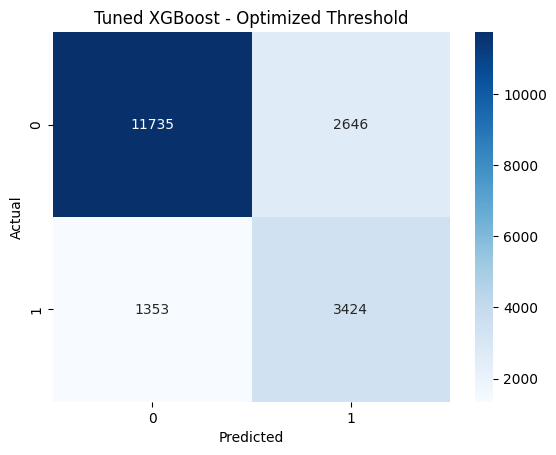

In [56]:
# Compare default threshold (0.50) vs optimized threshold
pred_default = (oof_prob >= 0.50).astype(int)
pred_optimized = (oof_prob >= best_threshold).astype(int)

comparison_threshold = pd.DataFrame({
    'Metric': ['Precision Class 1', 'Recall Class 1', 'F1 Class 1'],
    'Default Threshold 0.50': [
        precision_score(y_train, pred_default, zero_division=0),
        recall_score(y_train, pred_default, zero_division=0),
        f1_score(y_train, pred_default, zero_division=0)
    ],
    f'Optimized Threshold {best_threshold:.2f}': [
        precision_score(y_train, pred_optimized, zero_division=0),
        recall_score(y_train, pred_optimized, zero_division=0),
        f1_score(y_train, pred_optimized, zero_division=0)
    ]
})
display(comparison_threshold)

print('\nClassification Report - Optimized Threshold')
print(classification_report(y_train, pred_optimized, zero_division=0))

print('Confusion Matrix - Optimized Threshold')
cm = confusion_matrix(y_train, pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned XGBoost - Optimized Threshold')
plt.show()


#Models Evaluation

Running cross-validation for all models. This may take a few minutes...

Evaluating Logistic Regression (SMOTE)...
--- Logistic Regression (SMOTE) Classification Report ---
              precision    recall  f1-score   support

         0.0       0.89      0.75      0.81     14381
         1.0       0.49      0.71      0.58      4777

    accuracy                           0.74     19158
   macro avg       0.69      0.73      0.69     19158
weighted avg       0.79      0.74      0.75     19158

Evaluating Tuned Random Forest...
--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.72      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158

Evaluating Tuned XGBoost...
--- Tuned XGBoost Classification Report ---
              pre

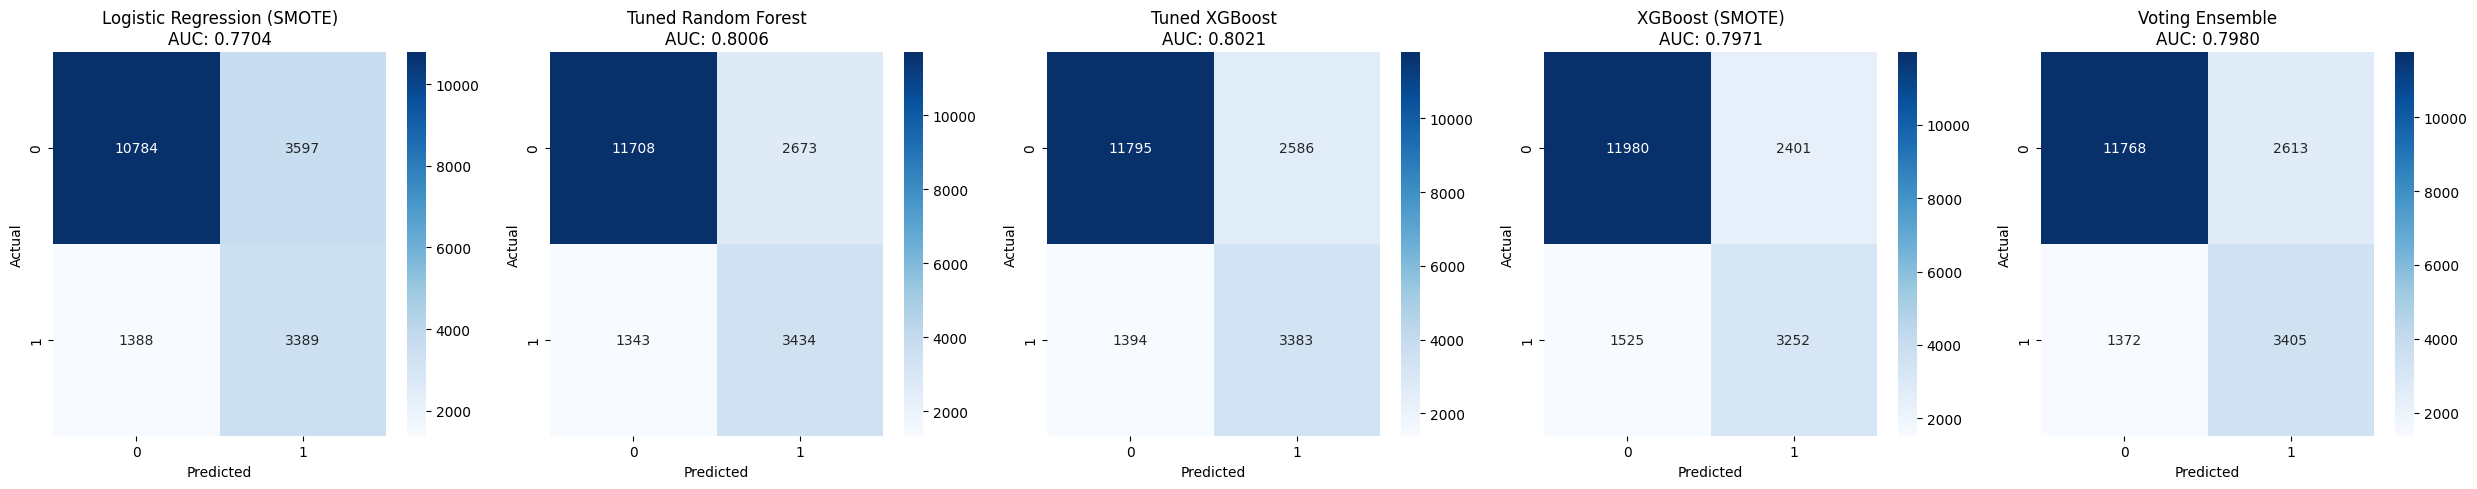

In [57]:
# 1. Define ALL the scikit-learn models you want to compare
# Ensure these variable names match exactly what is in your notebook memory
models_to_compare = {
    'Logistic Regression (SMOTE)': pipeline_lr_smote,
    'Tuned Random Forest': rf_random.best_estimator_,
    'Tuned XGBoost': best_xgb_pipeline,
    'XGBoost (SMOTE)': xgb_smote_pipeline,
    'Voting Ensemble': ensemble_smote_pipeline
}

n_models = len(models_to_compare)

# 2. Set up the plot dynamically to stretch based on how many models you have
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
comparison_data = []

print("Running cross-validation for all models. This may take a few minutes...\n")

# 3. Loop through each model to calculate metrics and plot
for i, (model_name, model) in enumerate(models_to_compare.items()):
    print(f"Evaluating {model_name}...")

    # Generate cross-validated predictions (n_jobs=-1 uses all CPU cores for speed)
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=-1)

    # Try to get probability predictions for the ROC-AUC score
    try:
        y_pred_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
        auc_score = roc_auc_score(y_train, y_pred_proba_cv)
    except:
        auc_score = np.nan

    # Calculate business metrics
    recall_1 = recall_score(y_train, y_pred_cv)
    precision_1 = precision_score(y_train, y_pred_cv)
    f1_1 = f1_score(y_train, y_pred_cv)

    # Store the data for the final summary table
    comparison_data.append({
        'Model': model_name,
        'ROC-AUC': auc_score,
        'Class 1 Recall': recall_1,
        'Class 1 Precision': precision_1,
        'Class 1 F1-Score': f1_1
    })

    # Print Classification Report to the console
    print(f"--- {model_name} Classification Report ---")
    print(classification_report(y_train, y_pred_cv))
    print("="*60)

    # Plot Confusion Matrix
    sns.heatmap(confusion_matrix(y_train, y_pred_cv), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{model_name}\nAUC: {auc_score:.4f}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Display the charts
plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', dpi=300) # Saves image for PowerPoint
plt.show()

##ROC Curves


Calculating probabilities and plotting ROC curves. This may take a moment...

Saved 'all_models_roc_comparison.png' to your directory.


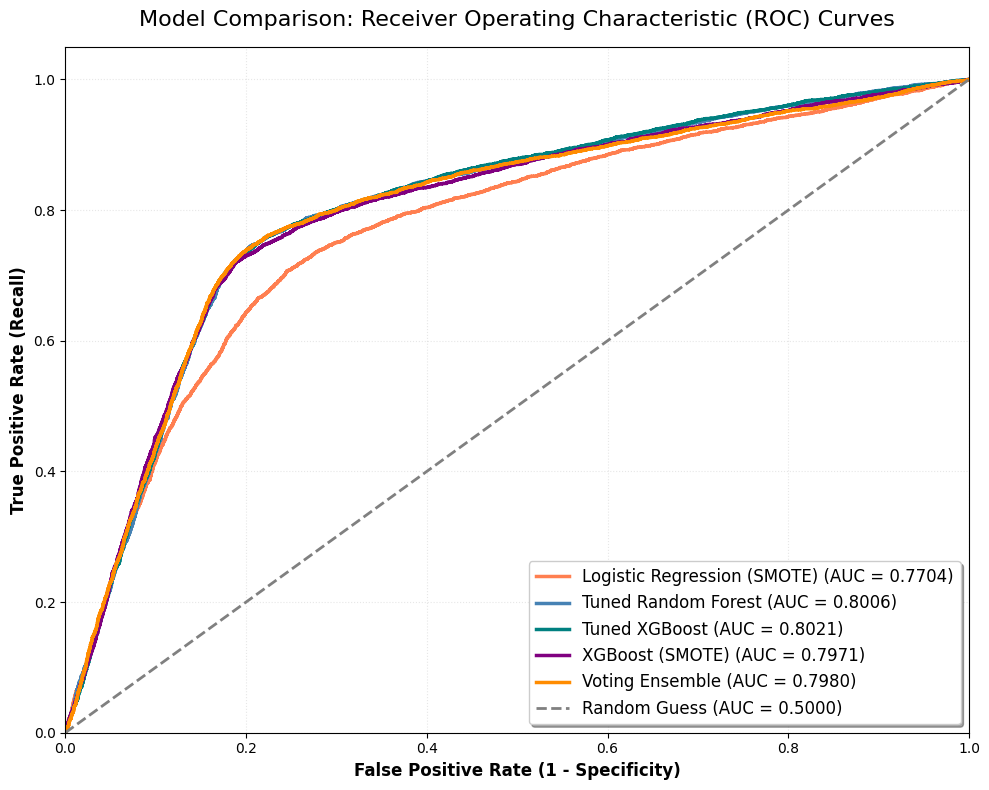

In [58]:


# 1. Define ALL the scikit-learn models you want to compare
models_to_compare = {
    'Logistic Regression (SMOTE)': pipeline_lr_smote,
    'Tuned Random Forest': rf_random.best_estimator_,
    'Tuned XGBoost': best_xgb_pipeline,
    'XGBoost (SMOTE)': xgb_smote_pipeline,
    'Voting Ensemble': ensemble_smote_pipeline
}

# 2. Add enough colors for all 5 models
colors = ['coral', 'steelblue', 'teal', 'purple', 'darkorange']

plt.figure(figsize=(10, 8))

print("Calculating probabilities and plotting ROC curves. This may take a moment...\n")

for (model_name, model), color in zip(models_to_compare.items(), colors):

    # Generate cross-validated probabilities (n_jobs=-1 speeds this up)
    y_pred_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and AUC
    fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_cv)
    roc_auc = auc(fpr, tpr)

    # Plot the curve for this specific model
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot the random guess diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guess (AUC = 0.5000)')

# Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('Model Comparison: Receiver Operating Characteristic (ROC) Curves', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()

plt.savefig('all_models_roc_comparison.png', dpi=300)
print("Saved 'all_models_roc_comparison.png' to your directory.")

plt.show()

In [59]:
# 4. Display the Final Summary Table ranked by ROC-AUC
summary_df = pd.DataFrame(comparison_data).sort_values(by='ROC-AUC', ascending=False)
print("\n=== FINAL MODEL COMPARISON SUMMARY ===")
display(summary_df)


=== FINAL MODEL COMPARISON SUMMARY ===


,Model,ROC-AUC,Class 1 Recall,Class 1 Precision,Class 1 F1-Score
2,Tuned XGBoost,0.802104,0.708185,0.566762,0.629630
1,Tuned Random Forest,0.800597,0.718861,0.562306,0.631018
4,Voting Ensemble,0.798009,0.712790,0.565803,0.630848
3,XGBoost (SMOTE),0.797127,0.680762,0.575270,0.623586
0,Logistic Regression (SMOTE),0.770370,0.709441,0.485113,0.576214


##Comparsion Table


=== MASTER MODEL COMPARISON ===
| Model                       |   ROC-AUC |   Class 1 Recall |   Class 1 Precision |   Class 1 F1-Score |
|:----------------------------|----------:|-----------------:|--------------------:|-------------------:|
| Tuned XGBoost               |  0.802104 |         0.708185 |            0.566762 |           0.62963  |
| Tuned Random Forest         |  0.800597 |         0.718861 |            0.562306 |           0.631018 |
| Voting Ensemble             |  0.798009 |         0.71279  |            0.565803 |           0.630848 |
| XGBoost (SMOTE)             |  0.797127 |         0.680762 |            0.57527  |           0.623586 |
| Logistic Regression (SMOTE) |  0.77037  |         0.709441 |            0.485113 |           0.576214 |


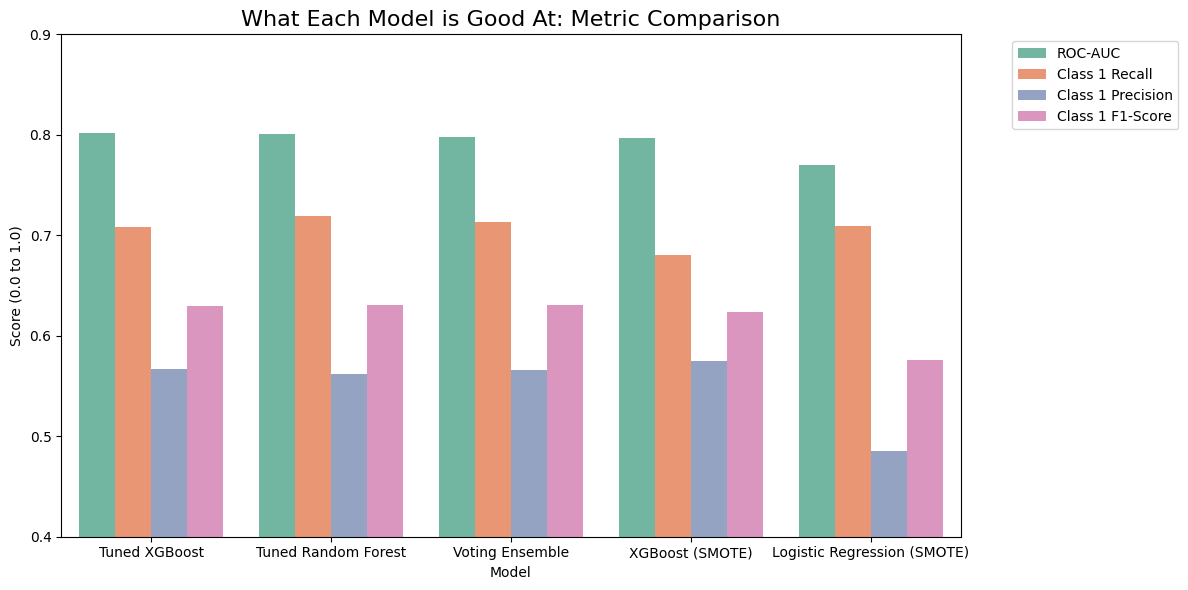

In [60]:
comparison_df = pd.DataFrame(comparison_data).sort_values(by='ROC-AUC', ascending=False)
print("\n=== MASTER MODEL COMPARISON ===")
print(comparison_df.to_markdown(index=False))

melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_df, palette='Set2')
plt.title('What Each Model is Good At: Metric Comparison', fontsize=16)
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0.4, 0.9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##Most Important Hiring Factors

In [61]:
dict(sorted(zip(rf_random.best_estimator_.feature_names_in_, rf_random.best_estimator_.feature_importances_), key=lambda x: x[1], reverse=True))

{'city_development_index': np.float64(0.32698238309091476),
 'company_size_encoded': np.float64(0.2276884451040336),
 'city_freq': np.float64(0.12126812536427249),
 'experience_encoded': np.float64(0.08205681299107337),
 'training_hours_capped': np.float64(0.0750824281651139),
 'education_level_encoded': np.float64(0.06578540423925425),
 'last_new_job_encoded': np.float64(0.039882291571630105),
 'enrolled_university_encoded': np.float64(0.03468035281168448),
 'relevent_experience_encoded': np.float64(0.02657375666202304)}

#Candidate Ranking System

In [62]:
best_xgb = best_xgb_pipeline
probabilities = best_xgb.predict_proba(X_test)[:, 1]
candidate_ranking = df_test.copy()
candidate_ranking['Probability'] = probabilities

candidate_ranking = candidate_ranking.sort_values(
    by='Probability',
    ascending=False
)

top_10_candidates = candidate_ranking.head(10).copy()

top_10_candidates.insert(
    0,
    'Rank',
    range(1, 11)
)
top_10_candidates['Recommendation'] = 'Recommended'

top_10_candidates[
    [
        'Rank',
        'enrollee_id',
        'education_level',
        'experience',
        'relevent_experience',
        'training_hours',
        'Probability',
        'Recommendation'
    ]
]

,Rank,enrollee_id,education_level,experience,relevent_experience,training_hours,Probability,Recommendation
1372,1,26993,Graduate,1,No relevent experience,54.0,0.801998,Recommended
23,2,5058,Graduate,1,No relevent experience,81.0,0.801646,Recommended
2003,3,32898,Graduate,1,No relevent experience,11.0,0.798840,Recommended
44,4,18133,Graduate,1,No relevent experience,23.0,0.795562,Recommended
355,5,23670,Graduate,2,No relevent experience,29.0,0.791564,Recommended
1976,6,20622,Graduate,2,No relevent experience,96.0,0.791199,Recommended
465,7,14601,Masters,1,Has relevent experience,14.0,0.787740,Recommended
139,8,15367,Graduate,<1,No relevent experience,24.0,0.786172,Recommended
575,9,26805,Graduate,<1,No relevent experience,41.0,0.783544,Recommended
491,10,28121,Graduate,5,Has relevent experience,17.0,0.782656,Recommended


#Candidate Predictions

In [63]:
#Final Predictions

X_test = df_test[X_train.columns]



predictions = best_xgb_pipeline.predict(X_test)


probabilities = best_xgb_pipeline.predict_proba(X_test)[:, 1]


submission_df = pd.DataFrame({
    'enrollee_id': df_test['enrollee_id'],
    'target': predictions,
    'flight_risk_probability': probabilities
})



file_name = 'final_candidate_predictions.csv'
submission_df.to_csv(file_name, index=False)

print("--- SUCCESS ---")
print(f"Predictions successfully saved to: {file_name}\n")

display(submission_df.head())

--- SUCCESS ---
Predictions successfully saved to: final_candidate_predictions.csv



,enrollee_id,target,flight_risk_probability
0,32403,0,0.183574
1,9858,1,0.700502
2,31806,1,0.692020
3,27385,0,0.208259
4,27724,0,0.222044


#Save Models

In [64]:
import pickle

best_rf = rf_random.best_estimator_

with open('/content/drive/MyDrive/Project ITI/best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Model saved successfully!")

Model saved successfully!


In [65]:
with open('/content/drive/MyDrive/Project ITI/best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_pipeline, f)

print("Tuned XGBoost model saved successfully!")

Tuned XGBoost model saved successfully!


#Exporting Processed Data

In [66]:
processed_train_path = '/content/drive/MyDrive/Project ITI/processed_aug_train.csv'
processed_test_path = '/content/drive/MyDrive/Project ITI/processed_aug_test.csv'

df_train.to_csv(processed_train_path, index=False)
df_test.to_csv(processed_test_path, index=False)

print(f"Processed training data saved to: {processed_train_path}")
print(f"Processed testing data saved to: {processed_test_path}")

Processed training data saved to: /content/drive/MyDrive/Project ITI/processed_aug_train.csv
Processed testing data saved to: /content/drive/MyDrive/Project ITI/processed_aug_test.csv
